# 02 — Prompt comparison
### Comparer baseline_prompt.txt et improved_prompt.txt sur les mêmes cas.
Mini batch check (sample d'image) pour vérifier la pertinence du model

### Import des libraries

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
from pathlib import Path

### Improved prompt with MedGemma

In [4]:
from pathlib import Path
import sys
sys.path.append(str(Path('..').resolve()))
from src.inference import vlm_predict_placeholder
from src.guardrails import apply_safety_guardrails

sample = Path('../data/sample_images/CXR_SYN_002_suspected_opacity.png')
apply_safety_guardrails(vlm_predict_placeholder(sample, mode='improved'))

ModuleNotFoundError: Could not import module 'AutoProcessor'. Are this object's requirements defined correctly?

### Baseline with MedGemma

In [ ]:
from pathlib import Path
import sys
sys.path.append(str(Path('..').resolve()))
from src.inference import vlm_predict_placeholder
from src.guardrails import apply_safety_guardrails

sample = Path('../data/sample_images/CXR_SYN_002_suspected_opacity.png')
apply_safety_guardrails(vlm_predict_placeholder(sample, mode='baseline'))

Le prompt "baseline" semble plus proche dela réalité que le "improved" avec le test sur l'image qui a une opacité suspectée.

### Check le nombre d'images disponibles et le temps pour tester le modèle

In [ ]:
data_root = Path('../data')
folders = ['normal_lung_probe', 'lung_images', 'abnormal_lung_images']
total = sum(len(list((data_root / f).glob('*.jpg'))) for f in folders)
print(f"Total images : {total}")
print(f"Temps estimé VLM : ~{total * 40 // 60} minutes")

### Resultat du mini batch
Run avec le fichier : scripts\ `run_batch.py` pour éviter les problèmes de gpu

In [18]:
# print batch_results.csv saved under results directory as csvfile
df_final = pd.read_csv('../results/batch_results.csv')
display(df_final)

,file,path,folder,ground_truth,toy_class,toy_confidence,vlm_baseline_class,vlm_baseline_confidence,vlm_improved_class,vlm_improved_confidence
0,NORMAL-LUNG_00115_normal_142.jpg,data\normal_lung_probe\NORMAL-LUNG_00115_norma...,normal_lung_probe,normal,normal,0.743,normal,0.95,normal,0.8
1,NORMAL-LUNG_00026_normal_036.jpg,data\normal_lung_probe\NORMAL-LUNG_00026_norma...,normal_lung_probe,normal,normal,0.730,normal,0.95,normal,0.8
2,NORMAL-LUNG_00282_normal_320.jpg,data\normal_lung_probe\NORMAL-LUNG_00282_norma...,normal_lung_probe,normal,normal,0.752,normal,0.95,normal,0.8
3,NORMAL-LUNG_00251_normal_285.jpg,data\normal_lung_probe\NORMAL-LUNG_00251_norma...,normal_lung_probe,normal,normal,0.728,normal,0.95,normal,0.8
4,NORMAL-LUNG_00229_normal_262.jpg,data\normal_lung_probe\NORMAL-LUNG_00229_norma...,normal_lung_probe,normal,normal,0.739,normal,0.95,normal,0.8
5,ABNORMAL-LUNG_00143_suspected_opacity_152.jpg,data\lung_images\ABNORMAL-LUNG_00143_suspected...,lung_images,suspected_opacity,suspected_opacity,0.704,normal,0.95,normal,0.8
6,NORMAL-LUNG_00755_normal_374.jpg,data\lung_images\NORMAL-LUNG_00755_normal_374.jpg,lung_images,normal,normal,0.731,normal,0.80,normal,0.8
7,ABNORMAL-LUNG_00105_suspected_opacity_112.jpg,data\lung_images\ABNORMAL-LUNG_00105_suspected...,lung_images,suspected_opacity,suspected_opacity,0.717,suspected_opacity,0.30,normal,0.8
8,NORMAL-LUNG_00693_normal_308.jpg,data\lung_images\NORMAL-LUNG_00693_normal_308.jpg,lung_images,normal,normal,0.747,normal,0.95,normal,0.8
9,NORMAL-LUNG_00759_normal_378.jpg,data\lung_images\NORMAL-LUNG_00759_normal_378.jpg,lung_images,normal,normal,0.714,normal,0.95,normal,0.8


### Calculs des métriques pour la comparaison


=== VLM Baseline ===
Taux uncertain : 6.7%
Accuracy : 64.3% (14 images)
Macro F1 : 0.524
Sensibilité (suspected_opacity) : 16.7%
Spécificité (normal) : 100.0%


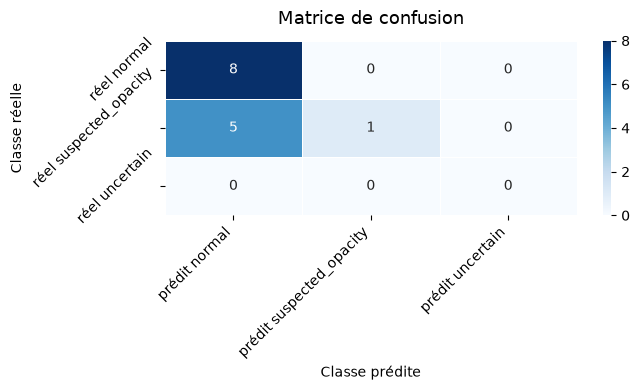


=== VLM Improved ===
Taux uncertain : 0.0%
Accuracy : 53.3% (15 images)
Macro F1 : 0.348
Sensibilité (suspected_opacity) : 0.0%
Spécificité (normal) : 100.0%


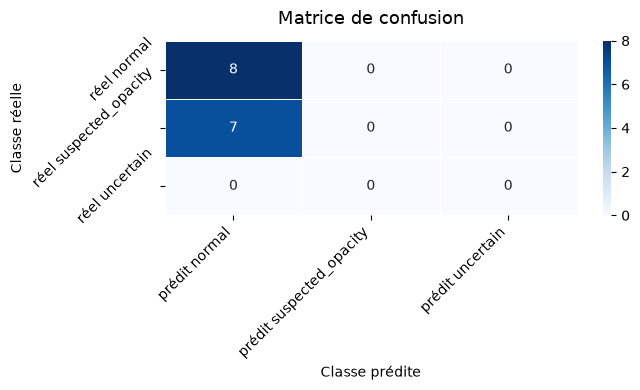

In [24]:
from sklearn.metrics import f1_score, recall_score, confusion_matrix
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt

modes = {
    'VLM Baseline': 'vlm_baseline_class',
    'VLM Improved': 'vlm_improved_class'
}

for label, col in modes.items():
    print(f"\n=== {label} ===")
    valid = df_final[df_final[col].notna() & (df_final[col] != 'error')].copy()
    
    # Taux uncertain
    uncertain_rate = (df_final[col] == 'uncertain').mean()
    print(f"Taux uncertain : {uncertain_rate:.1%}")
    
    # Exclure uncertain pour les métriques
    eval_df = valid[valid[col] != 'uncertain']
    y_true = eval_df['ground_truth']
    y_pred = eval_df[col]
    
    # Accuracy
    acc = (y_pred == y_true).mean()
    print(f"Accuracy : {acc:.1%} ({len(eval_df)} images)")
    
    # Macro F1
    f1 = f1_score(y_true, y_pred, average='macro', labels=['normal', 'suspected_opacity'], zero_division=0)
    print(f"Macro F1 : {f1:.3f}")
    
    # Sensibilité (rappel suspected_opacity)
    recall = recall_score(y_true, y_pred, pos_label='suspected_opacity', average='binary', zero_division=0)
    print(f"Sensibilité (suspected_opacity) : {recall:.1%}")
    
    # Spécificité (rappel normal)
    specificity = recall_score(y_true, y_pred, pos_label='normal', average='binary', zero_division=0)
    print(f"Spécificité (normal) : {specificity:.1%}")
    
    # Matrice de confusion
    labels = ['normal', 'suspected_opacity', 'uncertain']
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm,
        index=[f'réel {l}' for l in labels],
        columns=[f'prédit {l}' for l in labels])

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title('Matrice de confusion', fontsize=13, pad=12)
    ax.set_ylabel('Classe réelle')
    ax.set_xlabel('Classe prédite')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()